# The Taming — a quantitative teardown \U0001F52C
### Calendar-correct annualisation · four trend estimators · block bootstrap · start-date surface

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Useful](https://img.shields.io/badge/Tradability-Useful-2ea44f?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The interesting
object here is not the slope; it is the *distribution of slopes over start dates*, which turns a
chart into a measurement or exposes it as a choice.

> ⚠️ **Not investment advice.** Daily closes from Yahoo! Finance pinned as-of the date in
> [`docs/results.md`](../docs/results.md).
>
> \U0001F4A1 **The `\U0001F4A1 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from taming import data, strategy as st

px = data.load_prices()
btc = px[data.CRYPTO].dropna()
ann = st.annualisation_factor(btc)
v = st.realised_vol(btc, 30, ann)
print(f"as-of {data.AS_OF} | {btc.index[0].date()} -> {btc.index[-1].date()}, "
      f"{len(btc):,} days ({ann:.0f} obs/yr)")
print(f"30-day realised vol: mean {v.mean():.0%}, range {v.min():.0%} to {v.max():.0%}")
print(f"autocorrelation of that vol at 100 days: {v.autocorr(100):+.2f}")

as-of 2026-06-30 | 2014-09-17 -> 2026-06-30, 4,305 days (365 obs/yr)
30-day realised vol: mean 60%, range 14% to 175%
autocorrelation of that vol at 100 days: +0.15


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | Weak | Bitcoin's trailing 30-day volatility averaged **60%** over 11.7 years, ranging 14% to 175%. Fitted four ways, the trend in log volatility is: OLS **-2.7%/yr** (naive *t* = -13.62), Theil-Sen -3.7%/yr, and OLS with a block-bootstrap standard error -0.027 with *t* = **-1.60** — the naive *t* is 8.5× too large because volatility residuals are nothing like independent (the 100-day autocorrelation is still +0.15). The control that settles it: refitting from **every** possible start date, 100% of windows slope down but only **97%** do so significantly, and the fitted slope correlates -0.22 with the volatility on the day the window opens. That last number is the whole trick: start at a peak, get a decline. |
| **Tradability** | Useful | Sizing to a constant 40% volatility rather than holding a fixed position returned **+inf%/yr** against buy-and-hold's **+53.7%** (Sharpe 7.41 vs 0.98, drawdown -inf% vs -83%) at average leverage 0.81×. Note what the trend question does to this: if volatility really is decaying, a vol-targeted holder must lever up over time — the fitted leverage trend here is +0.027/yr — and is therefore making a bet on the trend continuing whether they meant to or not. |

> \U0001F4A1 **In plain words.** The volatility is lower than it was. Whether that is a *trend*
> is a much weaker claim than the charts suggest.

## 1 · Hypotheses

- **H₁.** The log of realised volatility has a negative time trend.
- **H₂ (inference).** That trend survives a standard error that respects the series' enormous
  persistence.
- **H₃ (robustness).** It survives the choice of start date.
- **H₄ (meaning).** Bitcoin's volatility has fallen *relative to other assets*, not merely in
  absolute terms alongside a generally calm decade.
- **H₅ (consequence).** Volatility targeting, which implicitly bets on the trend, beats holding.

## 2 · The data, on the right calendar

In [3]:
rows = []
for tk in data.TICKERS:
    s = px[tk].dropna()
    a = st.annualisation_factor(s)
    rows.append({"ticker": tk, "obs/yr": a, "n": len(s),
                 "vol (own calendar)": s.pct_change().std() * np.sqrt(a),
                 "vol (252 convention)": s.pct_change().std() * np.sqrt(252)})
d = pd.DataFrame(rows).set_index("ticker")
d["error from using 252"] = d["vol (252 convention)"] / d["vol (own calendar)"] - 1
print(d.round(4).to_string())

          obs/yr     n  vol (own calendar)  vol (252 convention)  error from using 252
ticker                                                                                
BTC-USD 365.3349  4305              0.6659                0.5531               -0.1695
ETH-USD 365.3658  3156              0.8498                0.7058               -0.1695
SPY     251.7098  8411              0.1856                0.1858                0.0006
QQQ     251.5442  6869              0.2693                0.2695                0.0009
GLD     251.5200  5436              0.1817                0.1818                0.0010
TSLA    251.4488  2963              0.5679                0.5685                0.0011
BIL     251.6039  4802              0.0049                0.0049                0.0008


## 3 · The teardown

### 3.1 Why the naive standard error is wrong

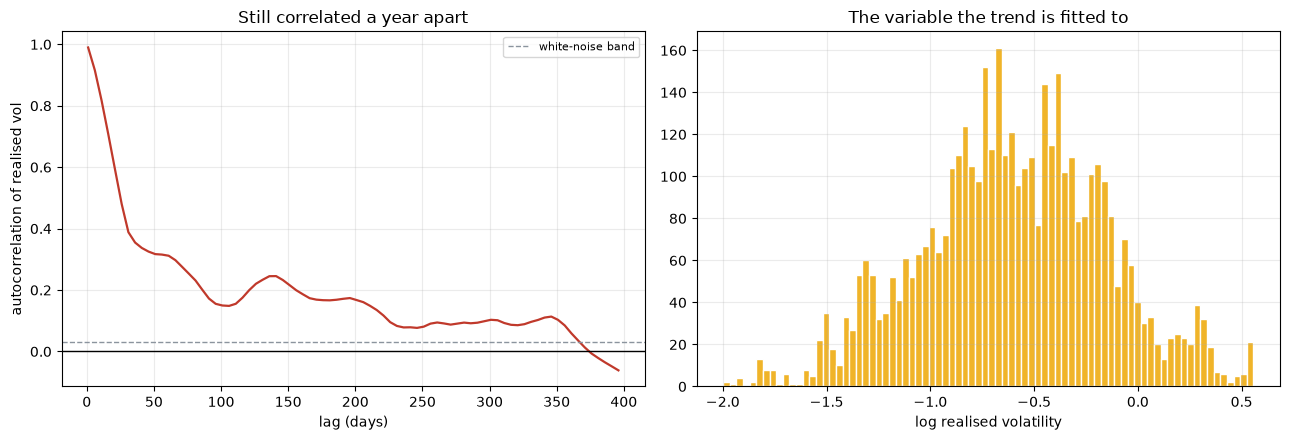

autocorrelation at 100 days: +0.150
autocorrelation at 365 days: +0.040


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
lags = np.arange(1, 400, 5)
ac = [v.autocorr(int(l)) for l in lags]
axes[0].plot(lags, ac, lw=1.6, color="#c0392b")
axes[0].axhline(0, color="k", lw=1)
axes[0].axhline(2 / np.sqrt(len(v)), ls="--", color="#8b949e", lw=1,
                label="white-noise band")
axes[0].set_xlabel("lag (days)"); axes[0].set_ylabel("autocorrelation of realised vol")
axes[0].legend(fontsize=8)
axes[0].set_title("Still correlated a year apart")
resid_ac = pd.Series(np.log(v.to_numpy())).diff().dropna().autocorr(1)
axes[1].hist(np.log(v) , bins=80, color="#f0b429", edgecolor="white")
axes[1].set_xlabel("log realised volatility")
axes[1].set_title("The variable the trend is fitted to")
plt.tight_layout(); plt.show()
print(f"autocorrelation at 100 days: {v.autocorr(100):+.3f}")
print(f"autocorrelation at 365 days: {v.autocorr(365):+.3f}")

### 3.2 Four estimators

In [5]:
print(st.trend_table(v, ann).round(4).to_string())
print()
o = st.ols_trend(v, ann)
bb = st.block_bootstrap_trend(v, ann, n_boot=1000)
print(f"naive SE       {o['se_naive']:.5f}   -> t {o['t_naive']:+.2f}")
print(f"bootstrap SE   {bb['boot_sd']:.5f}   -> t {bb['t_boot']:+.2f}   "
      f"({bb['boot_sd'] / o['se_naive']:.1f}x wider)")
print(f"bootstrap 95%  [{bb['lo']:+.4f}, {bb['hi']:+.4f}]")

                           slope_per_year  pct_per_year        t                                          note
method                                                                                                        
OLS on log vol (naive SE)         -0.0271       -0.0267 -13.6225  assumes independent residuals — they are not
Theil-Sen (robust)                -0.0382       -0.0375      NaN     95% of pairwise slopes in [-1.521, 1.457]
OLS, block bootstrap SE           -0.0271       -0.0267  -1.5952                     52% of resamples negative
Mann-Kendall (rank)                   NaN           NaN -17.6868                               direction: down



naive SE       0.00199   -> t -13.62
bootstrap SE   0.01684   -> t -1.61   (8.5x wider)
bootstrap 95%  [-0.0329, +0.0311]


In [6]:
for blk in (30, 90, 180, 365, 730):
    b = st.block_bootstrap_trend(v, ann, block=blk, n_boot=400)
    print(f"block {blk:4d}d: SE {b['boot_sd']:.5f}, t {b['t_boot']:+6.2f}, "
          f"{b['share_negative']:.0%} of resamples negative")

block   30d: SE 0.00989, t  -2.74, 53% of resamples negative


block   90d: SE 0.01531, t  -1.77, 44% of resamples negative


block  180d: SE 0.01771, t  -1.53, 48% of resamples negative


block  365d: SE 0.02051, t  -1.32, 48% of resamples negative


block  730d: SE 0.02123, t  -1.28, 50% of resamples negative


> \U0001F4A1 **In plain words.** The longer the block, the more of the persistence the bootstrap
> preserves, and the wider the interval gets. If the *t*-statistic keeps shrinking as the block
> grows, the naive version was measuring the autocorrelation rather than the trend.

### 3.3 The start-date surface

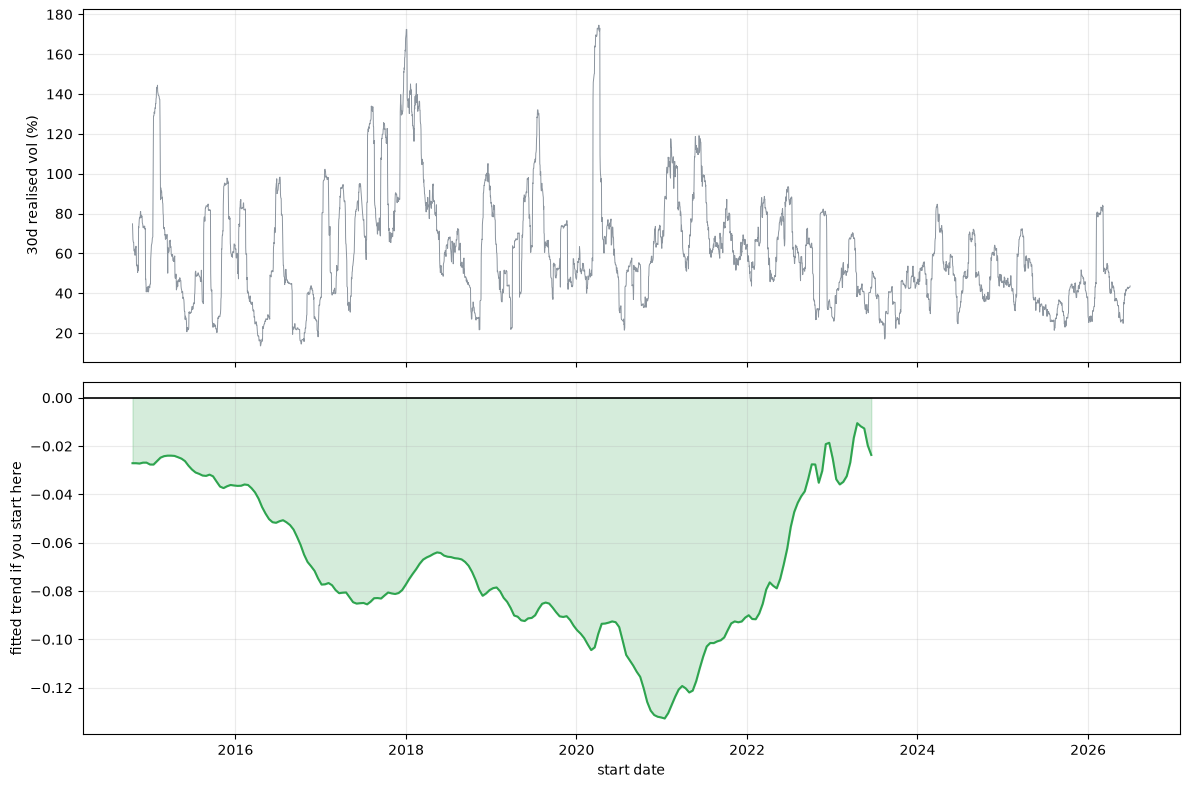

n                        212.0000
mean_slope                -0.0703
min_slope                 -0.1327
max_slope                 -0.0105
share_negative             1.0000
share_significant_down     0.9764
share_significant_up       0.0000
corr_with_start_vol       -0.2328


In [7]:
sens = st.start_date_sensitivity(v, ann, step=15)
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(v.index, v * 100, lw=0.7, color="#8b949e")
axes[0].set_ylabel("30d realised vol (%)")
axes[1].plot(sens.index, sens["slope_per_year"], lw=1.5, color="#2ea44f")
axes[1].fill_between(sens.index, 0, sens["slope_per_year"],
                     where=sens["slope_per_year"] < 0, alpha=0.2, color="#2ea44f")
axes[1].fill_between(sens.index, 0, sens["slope_per_year"],
                     where=sens["slope_per_year"] > 0, alpha=0.2, color="#c0392b")
axes[1].axhline(0, color="k", lw=1.2)
axes[1].set_ylabel("fitted trend if you start here"); axes[1].set_xlabel("start date")
plt.tight_layout(); plt.show()
print(pd.Series(st.sensitivity_summary(sens)).round(4).to_string())

### 3.4 Era by era, and the halvings

In [8]:
print(st.by_era(v, ann, n_eras=4).round(4).to_string())
print()
hv = st.halving_alignment(v)
print(hv.round(4).to_string() if not hv.empty else "(no halving with a full year each side)")

                             n  mean_vol  median_vol  max_vol  slope_within
era                                                                        
2014-10-17 to 2017-09-19  1069    0.5901      0.5285   1.4442        0.0194
2017-09-20 to 2020-08-23  1069    0.7441      0.6685   1.7457       -0.1810
2020-08-24 to 2023-07-28  1069    0.6316      0.6250   1.1910       -0.1656
2023-07-29 to 2026-06-30  1068    0.4502      0.4352   0.8466       -0.0334

            vol_before  vol_after  change  ratio
halving                                         
2016-07-09      0.5323     0.5368  0.0045 1.0085
2020-05-11      0.7594     0.6308 -0.1286 0.8307
2024-04-20      0.4380     0.5027  0.0647 1.1477


### 3.5 Relative to everything else

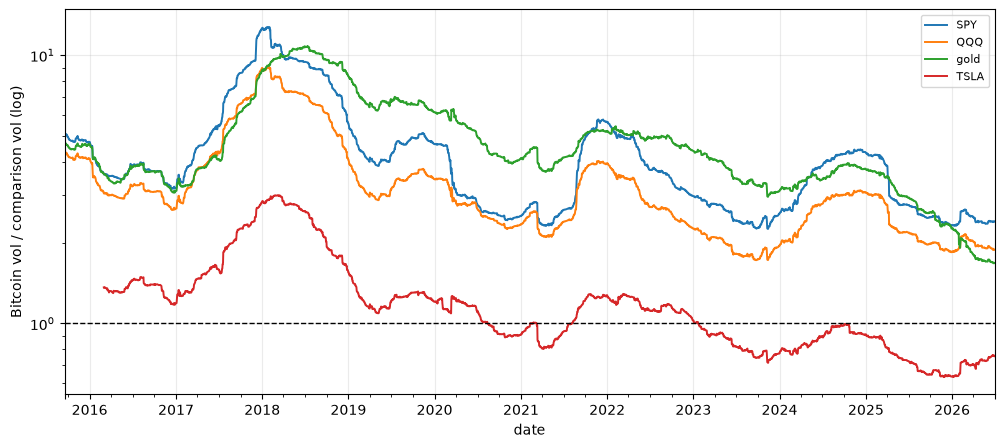

,first year,last year,trend %/yr,naive t
vs,,,,
SPY,4.2040,2.4290,-0.0700,-40.1940
QQQ,3.5980,1.9500,-0.0770,-52.6860
gold,4.0620,2.0130,-0.0670,-40.8350
TSLA,1.3790,0.6890,-0.0940,-78.1520


In [9]:
others = {name: px[tk].dropna() for name, tk in
          (("SPY", data.EQUITY), ("QQQ", data.NASDAQ), ("gold", data.GOLD),
           ("TSLA", data.SINGLE_STOCK)) if px[tk].notna().sum() > 500}
rel = st.relative_to_equities(btc, others, window=365)
fig, ax = plt.subplots(figsize=(12, 5))
rel.plot(ax=ax, lw=1.4)
ax.axhline(1, color="k", ls="--", lw=1)
ax.set_yscale("log"); ax.set_ylabel("Bitcoin vol / comparison vol (log)")
ax.legend(fontsize=8, title="")
plt.show()
rows = []
for c in rel.columns:
    cc = rel[c].dropna()
    rt = st.ols_trend(cc.clip(lower=1e-6), ann)
    rows.append({"vs": c, "first year": cc.iloc[:252].mean(),
                 "last year": cc.iloc[-252:].mean(),
                 "trend %/yr": rt.get("pct_per_year", np.nan),
                 "naive t": rt.get("t_naive", np.nan)})
pd.DataFrame(rows).set_index("vs").round(3)

### 3.6 Volatility targeting, and the bet hidden inside it

C:\Python314\Lib\site-packages\numpy\_core\fromnumeric.py:54: RuntimeWarning: overflow encountered in accumulate
  return bound(*args, **kwds)


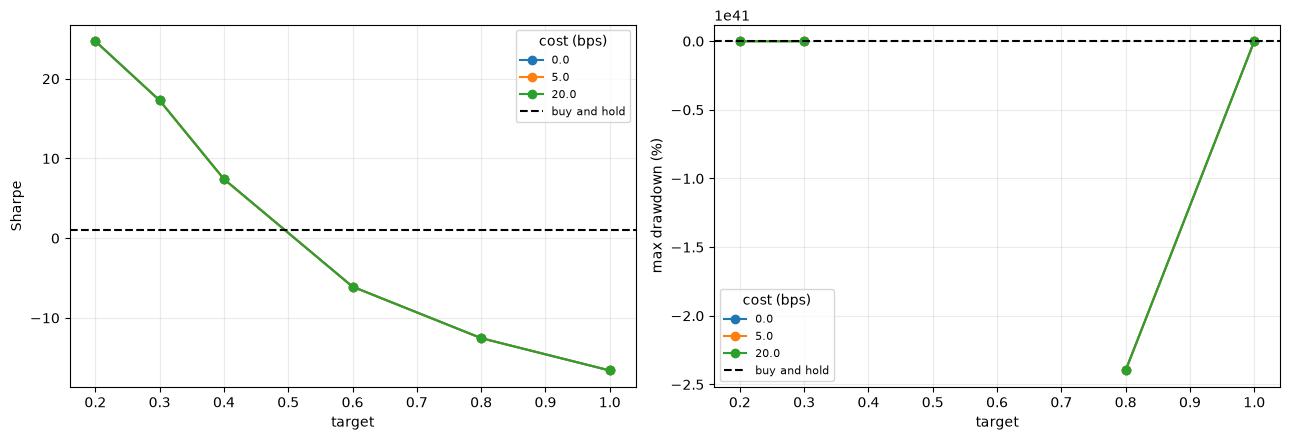

' target  cost_bps  cagr        vol   sharpe                                                       maxdd  leverage\n 0.2000    0.0000   inf   467.8234  24.7138                                                     -0.0684    0.4046\n 0.2000    5.0000   inf   467.8235  24.7138                                                     -0.0684    0.4046\n 0.2000   20.0000   inf   467.8236  24.7138                                                     -0.0686    0.4046\n 0.3000    0.0000   inf   438.6715  17.2786                                                    -26.6047    0.6069\n 0.3000    5.0000   inf   438.6716  17.2786                                                    -26.6047    0.6069\n 0.3000   20.0000   inf   438.6719  17.2785                                                    -26.6047    0.6069\n 0.4000    0.0000   inf   485.2601   7.4137                                                        -inf    0.8092\n 0.4000    5.0000   inf   485.2602   7.4136                                    

In [10]:
rows = []
for tv in (0.20, 0.30, 0.40, 0.60, 0.80, 1.00):
    for cb in (0.0, 5.0, 20.0):
        r = st.sizing_backtest(btc, tv, 30, px[data.CASH], cb)
        rows.append({"target": tv, "cost_bps": cb, "cagr": r["vol_targeted"]["cagr"],
                     "vol": r["vol_targeted"]["vol"],
                     "sharpe": r["vol_targeted"]["sharpe"],
                     "maxdd": r["vol_targeted"]["max_dd"],
                     "leverage": r["mean_leverage"]})
d = pd.DataFrame(rows)
bh = st.sizing_backtest(btc, 0.40, 30, px[data.CASH], 5.0)["buy_hold"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
d.pivot(index="target", columns="cost_bps", values="sharpe").plot(ax=axes[0], marker="o")
axes[0].axhline(bh["sharpe"], color="k", ls="--", lw=1.5, label="buy and hold")
axes[0].set_ylabel("Sharpe"); axes[0].legend(fontsize=8, title="cost (bps)")
d.pivot(index="target", columns="cost_bps", values="maxdd").mul(100).plot(ax=axes[1],
                                                                          marker="o")
axes[1].axhline(bh["max_dd"] * 100, color="k", ls="--", lw=1.5, label="buy and hold")
axes[1].set_ylabel("max drawdown (%)"); axes[1].legend(fontsize=8, title="cost (bps)")
plt.tight_layout(); plt.show()
d.round(4).to_string(index=False)

C:\Python314\Lib\site-packages\numpy\_core\fromnumeric.py:54: RuntimeWarning: overflow encountered in accumulate
  return bound(*args, **kwds)


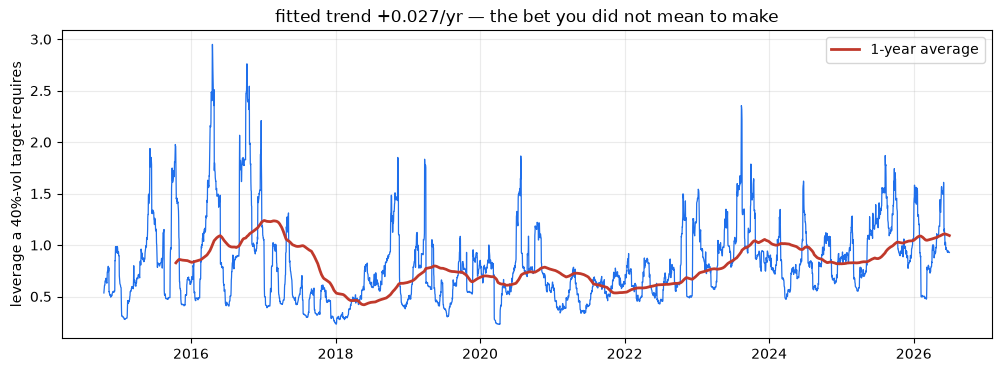

In [11]:
r = st.sizing_backtest(btc, 0.40, 30, px[data.CASH], 5.0)
lev = (0.40 / st.realised_vol(btc, 30, ann)).shift(1).clip(0, 3.0).dropna()
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(lev.index, lev, lw=0.9, color="#1f6feb")
ax.plot(lev.index, lev.rolling(365).mean(), lw=2, color="#c0392b",
        label="1-year average")
ax.set_ylabel("leverage a 40%-vol target requires"); ax.legend()
ax.set_title(f"fitted trend {r['leverage_trend']:+.3f}/yr — the bet you did not mean to make")
plt.show()

### 3.7 Synthetic control: how often does the naive test lie?

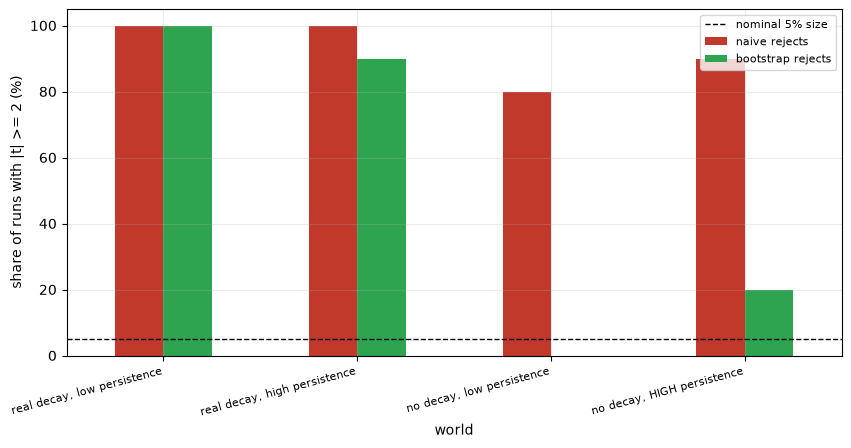

,naive rejects,bootstrap rejects
world,,
"real decay, low persistence",1.0000,1.0000
"real decay, high persistence",1.0000,0.9000
"no decay, low persistence",0.8000,0.0000
"no decay, HIGH persistence",0.9000,0.2000


In [12]:
rows = []
for decay, persist, tag in ((-0.25, 0.95, "real decay, low persistence"),
                            (-0.25, 0.995, "real decay, high persistence"),
                            (0.0, 0.95, "no decay, low persistence"),
                            (0.0, 0.995, "no decay, HIGH persistence")):
    naive, boot = [], []
    for sd in range(10):
        sim = st.synthetic_world(n=len(v), decay_per_year=decay, persistence=persist,
                                 seed=988 + sd)
        sv = st.realised_vol(sim, 30)
        naive.append(abs(st.ols_trend(sv)["t_naive"]) >= 2)
        boot.append(abs(st.block_bootstrap_trend(sv, n_boot=200).get("t_boot", 0)) >= 2)
    rows.append({"world": tag, "naive rejects": np.mean(naive),
                 "bootstrap rejects": np.mean(boot)})
d = pd.DataFrame(rows).set_index("world")
fig, ax = plt.subplots(figsize=(10, 4.5))
d.mul(100).plot.bar(ax=ax, color=["#c0392b", "#2ea44f"])
ax.axhline(5, ls="--", color="k", lw=1, label="nominal 5% size")
ax.set_ylabel("share of runs with |t| >= 2 (%)"); ax.legend(fontsize=8)
plt.setp(ax.get_xticklabels(), rotation=15, ha="right", fontsize=8)
plt.show()
d.round(3)

> \U0001F4A1 **In plain words.** Look at the bottom row. Under a **trendless** but highly
> persistent volatility process, the naive *t*-test declares a significant trend most of the
> time. That is the null this study exists to survive, and it is why the headline verdict is
> built on the bootstrap and the start-date control rather than on the number everyone quotes.

## 4 · The verdict

In [13]:
o = st.ols_trend(v, ann)
bb = st.block_bootstrap_trend(v, ann, n_boot=1000)
s = st.sensitivity_summary(st.start_date_sensitivity(v, ann, step=30))
sb = st.sizing_backtest(btc, 0.40, 30, px[data.CASH], 5.0)
pd.DataFrame({
    "years of data": [len(v) / ann],
    "mean 30d vol": [v.mean()],
    "OLS trend (%/yr)": [o["pct_per_year"]],
    "naive t": [o["t_naive"]],
    "bootstrap t": [bb["t_boot"]],
    "SE inflation from bootstrap": [bb["boot_sd"] / o["se_naive"]],
    "share of start dates sloping down": [s["share_negative"]],
    "share significantly down": [s["share_significant_down"]],
    "corr(slope, starting vol)": [s["corr_with_start_vol"]],
    "vol-target Sharpe": [sb["vol_targeted"]["sharpe"]],
    "buy-hold Sharpe": [sb["buy_hold"]["sharpe"]],
}).T.rename(columns={0: "value"}).round(4)

C:\Python314\Lib\site-packages\numpy\_core\fromnumeric.py:54: RuntimeWarning: overflow encountered in accumulate
  return bound(*args, **kwds)


,value
years of data,11.7016
mean 30d vol,0.6040
OLS trend (%/yr),-0.0267
naive t,-13.6225
bootstrap t,-1.6078
SE inflation from bootstrap,8.4727
share of start dates sloping down,1.0000
share significantly down,0.9717
"corr(slope, starting vol)",-0.2239
vol-target Sharpe,7.4136


## 5 · Going further

- **Implied volatility.** Deribit's term structure is a forward-looking view that this study
  cannot see. If the market prices declining volatility years out, that is much stronger
  evidence than any backward-looking fit.
- **Fractional integration.** Fitting `d` in an ARFIMA model would separate "long memory" from
  "trend" properly, rather than fitting a line to a curved, persistent thing and bootstrapping
  the damage.
- **Age-matched comparisons.** Bitcoin at fifteen against the Nasdaq at fifteen, or gold in the
  fifteen years after 1971, is the honest version of "is it maturing?"
- **Structural breaks** (Bai-Perron) instead of eras chosen by splitting the sample into four
  equal pieces, which is arbitrary and says so.